In [1]:
from pathlib import Path
import numpy as np
from latency_evt_tools import (
    find_parquet_files,           # Recursively list *.parquet (limit via max_files/sample/seed)
    collect_block_maxima,         # Per-file latency max → np.ndarray (supports per_dir + time window)
    fit_gev,                      # Fit GEV (SciPy): returns (c, loc, scale) where c = -xi
    gev_params_dict,              # Pretty params dict including xi
    gev_quantiles,                # Get quantiles (e.g., p99/p999) from fitted GEV
    return_level,                 # T-block return level: F^{-1}(1 - 1/T)
    summarize_block_maxima,       # Quick stats for block maxima (count/mean/std/pXX)
    save_block_maxima_csv,        # Persist block maxima to CSV
    fit_gev_from_dir,             # One-shot: dir → maxima + GEV fit + requested quantiles
    analyze_parquet_dir,          # End-to-end pipeline (limiting, per_dir, time window, optional save_dir)
    gev_ks_test,                  # KS goodness-of-fit test for GEV
    plot_hist_with_gev,           # Histogram of maxima with GEV PDF overlay (matplotlib)
    plot_qq_gev,                  # Q–Q plot (empirical vs theoretical GEV quantiles)
    plot_pp_gev,                  # P–P plot (empirical CDF vs model CDF)
    throughput_from_parquet_dir,  # Time-series throughput (msgs/bytes/MB/s) with same limiting/window options
    summarize_throughput,         # Summary of throughput (means/medians + MB/s percentiles)
    debug_throughput_scan,        # Diagnose which time/size columns used + time span/granularity
    select_files_per_subdir,      # Pick N files per “shard” (subdirectory) with sampling strategy
    simple_merge_metrics,         # Straightforward metrics (latency pXX, overall throughput, quick GEV), max_files knob
)


In [26]:
#dir = "../results/20250918_165513/consumer/consumer-sts-0_consumer-result/"
dir = "../results/20250918_165513/consumer/consumer-sts-0_consumer-result/2025-09-15/"


res = analyze_parquet_dir(
    root=dir,
    col="end_to_end_latency_seconds",             # latency column 
    probs=(0.95, 0.99, 0.999, 0.9999), 
    save_dir="./evt_out",             
    max_files=None,                                # for all files: max_files = 0 or max_files = None
    sample="head"                                 # can be set to "random" or "even" or "tail"
)

In [1]:
import pandas as pd
df = pd.read_parquet("../results/20250918_165513/consumer/consumer-sts-0_consumer-result/2025-09-15/21-46-46/batch_consumer-sts-5_20250917_214059_177473.parquet" )
df.columns

Index(['index', 'producer_timestamp', 'consumer_receive_timestamp',
       'application_timestamp', 'application_latency_seconds',
       'end_to_end_latency_seconds', 'size_bytes', 'target_rate', 'topic',
       'partition', 'offset'],
      dtype='object')

In [27]:

print(res["files_found"], "files scanned")
print("Blocks used:", res["block_count"])
print("GEV params:", res["params"])       # {'shape_c': c, 'xi': xi, 'loc': loc, 'scale': scale}
print("Quantiles:", res["quantiles"])     # {0.95: ..., 0.99: ..., ...}
bm = res["block_maxima"]                  # numpy array of per-file maxima


142833 files scanned
Blocks used: 142833
GEV params: {'shape_c': -0.10442299173446978, 'xi': 0.10442299173446978, 'loc': 0.5161903094074155, 'scale': 0.016448135331526656}
Quantiles: {0.95: 0.5734686843572901, 0.99: 0.6133229596030799, 0.999: 0.6826920878562686, 0.9999: 0.7707830436150691}


In [28]:
rl_1hr = return_level(60, res["params"]["shape_c"], res["params"]["loc"], res["params"]["scale"])
rl_1hr

0.6000105488601665

In [29]:
params = res["params"]
quants = res["quantiles"]

to_ms = lambda s: 1000.0 * s

print("p95 (ms):  ", to_ms(quants[0.95]))
print("p99 (ms):  ", to_ms(quants[0.99]))
print("p99.9 (ms):", to_ms(quants[0.999]))
print("p99.99 (ms):", to_ms(quants[0.9999]))

# Weibull (bounded) upper endpoint when xi<0:
# endpoint = loc - scale/xi  ==  loc + scale/c  (because c = -xi in SciPy)
endpoint_sec = params["loc"] + params["scale"]/params["shape_c"]
print("Theoretical upper bound (ms):", to_ms(endpoint_sec))


p95 (ms):   573.4686843572902
p99 (ms):   613.3229596030799
p99.9 (ms): 682.6920878562686
p99.99 (ms): 770.7830436150691
Theoretical upper bound (ms): 358.6758094077266


KS: {'stat': 0.17218038360885013, 'pvalue': 0.0}


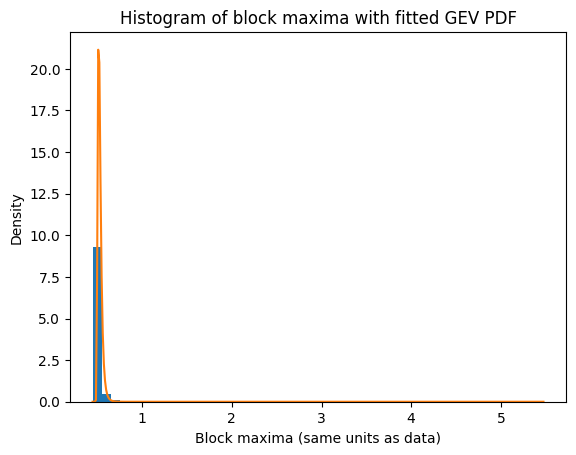

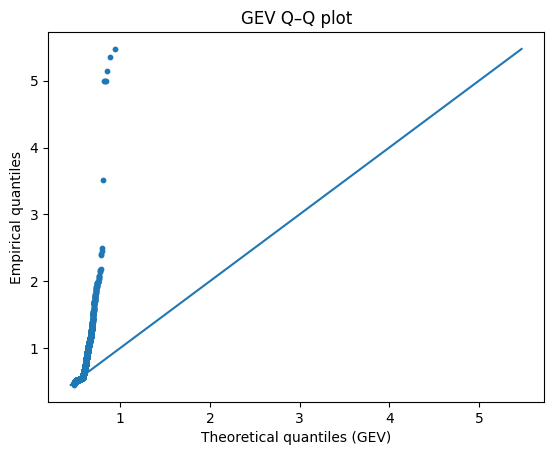

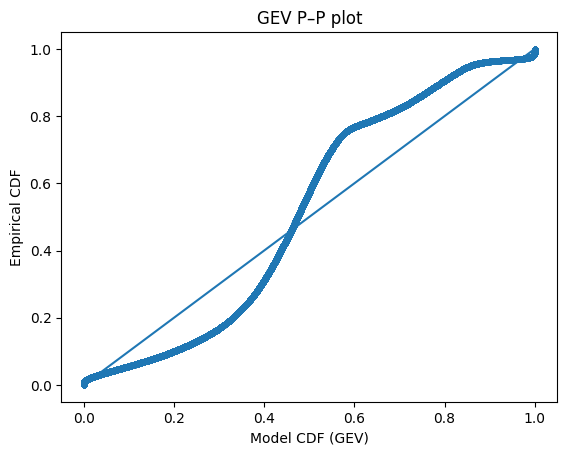

In [30]:
c = res["params"]["shape_c"]; loc = res["params"]["loc"]; scale = res["params"]["scale"]

print("KS:", gev_ks_test(bm, c, loc, scale))  # {'stat': D, 'pvalue': p}
plot_hist_with_gev(bm, c, loc, scale)         # histogram + fitted PDF
plot_qq_gev(bm, c, loc, scale)                # Q–Q alignment
plot_pp_gev(bm, c, loc, scale)                # P–P alignment


In [33]:
# Auto-detect columns; or time_col="app_done_ts", size_col="size_bytes"
ts = throughput_from_parquet_dir(
    dir,
    time_col="app_done_ts",    
    size_col="size_bytes",
    resample="1S",
    max_files=2000,              
    sample="head"
)
print(summarize_throughput(ts))  

# If you need per-minute instead:
#ts_min = throughput_from_parquet_dir(dir, resample="1T")

{'MBps_mean': 6250.0, 'MBps_median': 6250.0, 'MBps_p50': 6250.0, 'MBps_p90': 6250.0, 'MBps_p95': 6250.0, 'MBps_p99': 6250.0, 'msgs_mean': 200000.0, 'msgs_median': 200000.0}


In [34]:
info = debug_throughput_scan(
    dir,
    time_col="app_done_ts",   
    size_col="size_bytes",
    max_files=2000          
)
info


{'files_scanned': 2000,
 'rows_total': 200000,
 'time_col_used': 'producer_timestamp',
 'size_col_used': 'size_bytes',
 'time_min': '1970-01-01 00:00:01.757994411',
 'time_max': '1970-01-01 00:00:01.758007282',
 'time_span_sec': 1.2e-05,
 'unique_seconds': 1,
 'unique_minutes': 1,
 'example_times': ['1970-01-01 00:00:01.757994412',
  '1970-01-01 00:00:01.757994413',
  '1970-01-01 00:00:01.757994413',
  '1970-01-01 00:00:01.757994413',
  '1970-01-01 00:00:01.757994413']}

In [ ]:
from latency_evt_tools import simple_merge_metrics

# Read only 50 Parquet files (first 50 after sort)
m = simple_merge_metrics(
    root=dir,
    latency_col="e2e_latency_ms",  
    time_col="app_done_ts",        
    size_col="size_bytes",         
    max_files=100,                  
    sample="head"                  # or 'tail' 'random' 'even'
)
print(m)


In [ ]:
info = debug_throughput_scan(
    dir,
    time_col="app_done_ts",      
    size_col="size_bytes",     
    max_files=500
)
info